# Emotion Detection

**Importing Libraries**

In [3]:
from datetime import datetime
from pathlib import Path
import hashlib
import math
import os
import json
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Activation,
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    Input,
    MaxPooling2D,
)
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

%matplotlib inline

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "model_a1.json").is_file():
    raise FileNotFoundError(
        f"Open this notebook with the project directory as its working folder; "
        f"model_a1.json was not found in {PROJECT_DIR}"
    )

print("Project directory:", PROJECT_DIR)
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("OpenCV version:", cv2.__version__)

Project directory: C:\Users\vipin\Downloads\Emotion_detection-main\Emotion_detection-main
TensorFlow version: 2.15.1
NumPy version: 1.26.4
OpenCV version: 4.10.0


**Exploring Dataset**

Dataset directory: D:\datasets\fer2013
Removed redundant same-split duplicates: 1211
Removed test images duplicated in train: 539
Removed images with conflicting labels: 160
Train: 27418 readable images; test: 6559
Class folders: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


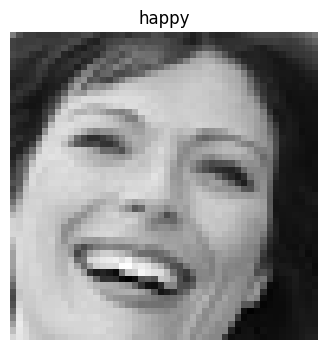

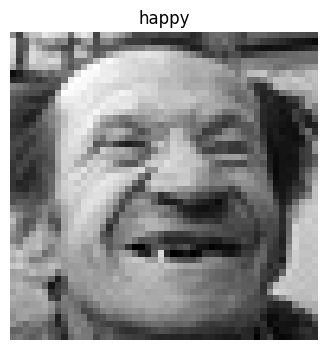

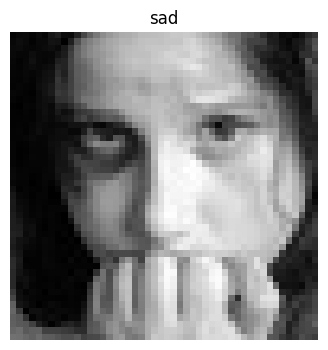

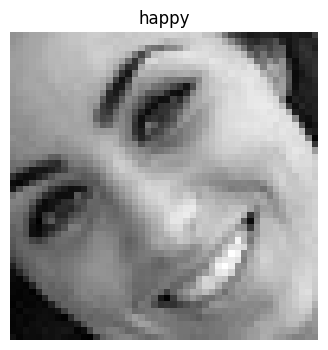

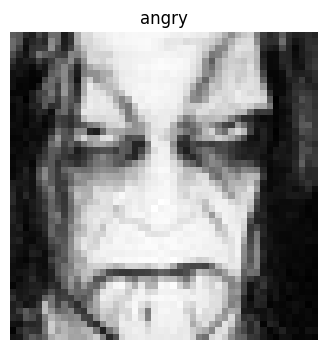

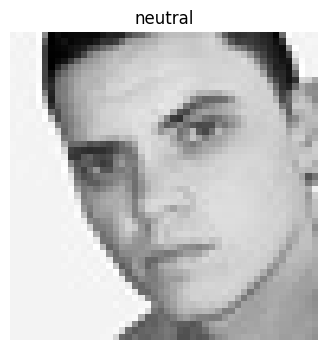

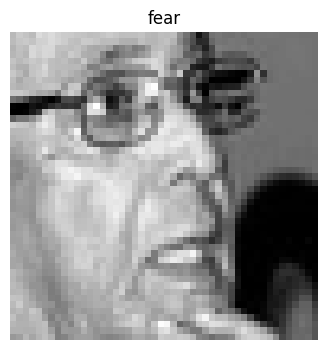

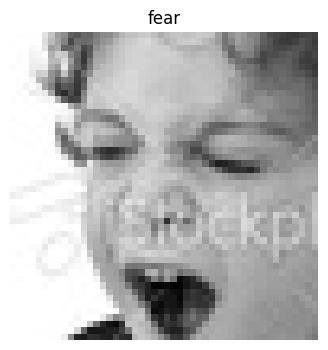

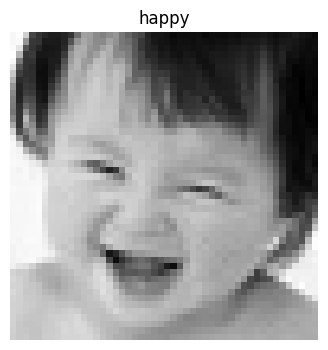

In [4]:
default_dataset_dir = Path(r"D:\datasets\fer2013")
dataset_root = os.environ.get("FER_DATASET_DIR")
if dataset_root:
    DATASET_DIR = Path(dataset_root).expanduser().resolve()
elif (default_dataset_dir / "train").is_dir() and (
    default_dataset_dir / "test"
).is_dir():
    DATASET_DIR = default_dataset_dir
else:
    DATASET_DIR = PROJECT_DIR
train_dir = DATASET_DIR / "train"
test_dir = DATASET_DIR / "test"
image_extensions = {
    ".jpg", ".jpeg", ".jpe", ".png", ".bmp", ".dib", ".tif", ".tiff",
    ".webp", ".jp2", ".pbm", ".pgm", ".ppm", ".pnm", ".pfm", ".sr", ".ras",
}
expected_class_names = [
    "angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"
]

print("Dataset directory:", DATASET_DIR)
if not train_dir.is_dir() or not test_dir.is_dir():
    raise FileNotFoundError(
        "FER image dataset not found. Set FER_DATASET_DIR to a directory "
        "containing separate train/ and test/ folders, or add them under "
        f"{PROJECT_DIR}. Each split needs class folders angry, disgust, fear, "
        "happy, neutral, sad, and surprise."
    )
train_root = train_dir.resolve()
test_root = test_dir.resolve()
if (
    train_root == test_root
    or train_root.is_relative_to(test_root)
    or test_root.is_relative_to(train_root)
):
    raise ValueError(
        "Training and test datasets must be separate, non-overlapping directories."
    )

def inspect_dataset_split(split_dir):
    class_dirs = sorted(path for path in split_dir.iterdir() if path.is_dir())
    if not class_dirs:
        raise ValueError(f"No class subfolders found in {split_dir}")

    samples = []
    unreadable = []
    unsupported = []
    for class_dir in class_dirs:
        class_files = sorted(path for path in class_dir.rglob("*") if path.is_file())
        files = [path for path in class_files if path.suffix.lower() in image_extensions]
        unsupported.extend(path for path in class_files if path.suffix.lower() not in image_extensions)
        if not files:
            raise ValueError(f"No supported images found for class {class_dir.name}")
        class_samples = []
        for image_path in files:
            image = cv2.imread(str(image_path))
            if image is None:
                unreadable.append(image_path)
            else:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                class_samples.append((image_path, class_dir.name))
        if not class_samples:
            raise ValueError(f"No readable images found for class {class_dir.name}")
        samples.extend(class_samples)

    if unreadable:
        examples = ", ".join(str(path) for path in unreadable[:5])
        print(
            f"Skipping {len(unreadable)} unreadable image(s) in {split_dir}. "
            f"Examples: {examples}"
        )
    if unsupported:
        print(f"Ignoring {len(unsupported)} unsupported file(s) in {split_dir}.")
    return samples, [path.name for path in class_dirs]

train_samples, train_class_names = inspect_dataset_split(train_dir)
test_samples, test_class_names = inspect_dataset_split(test_dir)
if {name.casefold() for name in train_class_names} != {name.casefold() for name in test_class_names}:
    raise ValueError(
        "Train/test class folders differ: "
        f"train={train_class_names}, test={test_class_names}"
    )
train_names_by_casefold = {name.casefold(): name for name in train_class_names}
if len(train_names_by_casefold) != len(train_class_names):
    raise ValueError("Class directory names collide when compared case-insensitively.")
if set(train_names_by_casefold) != set(expected_class_names):
    raise ValueError(
        "Dataset classes must match the GUI's seven output labels "
        f"{expected_class_names}; found {train_class_names}"
    )
class_names = [train_names_by_casefold[name] for name in expected_class_names]

records_by_hash = {}
for split_name, samples in (("train", train_samples), ("test", test_samples)):
    for image_path, label in samples:
        image_hash = hashlib.sha256(image_path.read_bytes()).digest()
        record = records_by_hash.setdefault(
            image_hash, {"train": [], "test": [], "labels": set()}
        )
        record[split_name].append((image_path, label))
        record["labels"].add(label.casefold())

deduplicated_train = []
deduplicated_test = []
same_split_duplicates = 0
test_duplicates_of_train = 0
ambiguous_label_images = 0
train_hashes = set()
test_hashes = set()
for image_hash, record in records_by_hash.items():
    train_entries = record["train"]
    test_entries = record["test"]
    if len(record["labels"]) > 1:
        ambiguous_label_images += len(train_entries) + len(test_entries)
        continue
    if train_entries:
        deduplicated_train.append(train_entries[0])
        train_hashes.add(image_hash)
        same_split_duplicates += len(train_entries) - 1
        test_duplicates_of_train += len(test_entries)
    elif test_entries:
        deduplicated_test.append(test_entries[0])
        test_hashes.add(image_hash)
        same_split_duplicates += len(test_entries) - 1
if train_hashes & test_hashes:
    raise ValueError(
        "Duplicate image content remains across training and test splits."
    )
train_samples = deduplicated_train
test_samples = deduplicated_test
print("Removed redundant same-split duplicates:", same_split_duplicates)
print("Removed test images duplicated in train:", test_duplicates_of_train)
print("Removed images with conflicting labels:", ambiguous_label_images)

print(f"Train: {len(train_samples)} readable images; test: {len(test_samples)}")
print("Class folders:", class_names)
for image_path, label in random.sample(train_samples, k=min(9, len(train_samples))):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray")
    plt.title(label)
    plt.axis("off")
    plt.show()

**Preparing Data for Training**

In [5]:
img_size = 48
batch_size = 64
validation_fraction = 0.2
class_indices = {name: index for index, name in enumerate(expected_class_names)}
train_labels = [class_indices[label.casefold()] for _, label in train_samples]
test_labels = [class_indices[label.casefold()] for _, label in test_samples]
class_counts = np.bincount(train_labels, minlength=len(class_names))
test_class_counts = np.bincount(test_labels, minlength=len(class_names))
if np.any(test_class_counts == 0):
    raise ValueError(
        "The held-out test split needs at least one readable image per class; "
        f"counts={test_class_counts.tolist()}"
    )
if np.any(class_counts < 2):
    raise ValueError(
        "Each emotion class needs at least two readable training images for "
        f"a stratified train/validation split; counts={class_counts.tolist()}"
    )
validation_count = math.ceil(len(train_samples) * validation_fraction)
if validation_count < len(class_names) or len(train_samples) - validation_count < len(class_names):
    raise ValueError(
        "Not enough training images to place every class in both training "
        "and validation subsets."
    )
train_indices, validation_indices = train_test_split(
    np.arange(len(train_samples)),
    test_size=validation_fraction,
    random_state=42,
    stratify=train_labels,
)

class EmotionImageSequence(Sequence):
    def __init__(self, samples, class_indices, batch_size, shuffle=False, seed=42):
        self.samples = [
            (path, class_indices[label.casefold()]) for path, label in samples
        ]
        self.class_indices = class_indices
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)
        self.indices = np.arange(len(self.samples))
        self.classes = np.array([label for _, label in self.samples], dtype=np.int64)
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.samples) / self.batch_size)

    def __getitem__(self, batch_index):
        if batch_index < 0 or batch_index >= len(self):
            raise IndexError(f"Batch index out of range: {batch_index}")
        batch_indices = self.indices[
            batch_index * self.batch_size : (batch_index + 1) * self.batch_size
        ]
        batch_images = np.empty(
            (len(batch_indices), img_size, img_size, 1), dtype=np.float32
        )
        batch_labels = np.zeros(
            (len(batch_indices), len(self.class_indices)), dtype=np.float32
        )
        for output_index, sample_index in enumerate(batch_indices):
            image_path, label_index = self.samples[sample_index]
            image = cv2.imread(str(image_path))
            if image is None:
                raise ValueError(f"Image became unreadable after validation: {image_path}")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            image = cv2.resize(
                image, (img_size, img_size), interpolation=cv2.INTER_LINEAR
            )
            batch_images[output_index, :, :, 0] = image
            batch_labels[output_index, label_index] = 1.0
        return batch_images, batch_labels

    def on_epoch_end(self):
        self.indices = np.arange(len(self.samples))
        if self.shuffle:
            self.rng.shuffle(self.indices)

    def reset(self):
        self.indices = np.arange(len(self.samples))

train_subset = [train_samples[index] for index in train_indices]
validation_subset = [train_samples[index] for index in validation_indices]
train_generator = EmotionImageSequence(
    train_subset, class_indices, batch_size, shuffle=True
)
validation_generator = EmotionImageSequence(
    validation_subset, class_indices, batch_size, shuffle=False
)
test_generator = EmotionImageSequence(
    test_samples, class_indices, batch_size, shuffle=False
)
print("Class index mapping (aligned with gui.py):", class_indices)
print("Training samples:", len(train_subset))
print("Validation samples:", len(validation_subset))
print("Held-out test samples:", len(test_samples))
print("Image pixel range: 0..255 (no normalization; matches gui.py)")
print("Image preprocessing: OpenCV grayscale and INTER_LINEAR resize to 48x48")

Class index mapping (aligned with gui.py): {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Training samples: 21934
Validation samples: 5484
Held-out test samples: 6559
Image pixel range: 0..255 (no normalization; matches gui.py)
Image preprocessing: OpenCV grayscale and INTER_LINEAR resize to 48x48


**Defining Model**

In [8]:
def Convolution(input_tensor, filters, kernel_size):
    x = Conv2D(filters = filters, kernel_size = kernel_size, padding = "same")(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size = (2,2))(x)
    x = Dropout(0.25)(x)
    
    return x

In [9]:
def Dense_f(input_tensor, nodes):
    x = Dense(nodes)(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    
    return x

In [11]:
def model_fer(input_shape=(48, 48, 1), number_of_classes=7):
    inputs = Input(shape=input_shape)
    conv_1 = Convolution(inputs, 64, (3, 3))
    conv_2 = Convolution(conv_1, 128, (5, 5))
    conv_3 = Convolution(conv_2, 512, (3, 3))
    conv_4 = Convolution(conv_3, 512, (3, 3))

    flatten = Flatten()(conv_4)
    dense_1 = Dense_f(flatten, 256)
    dense_2 = Dense_f(dense_1, 512)
    output = Dense(number_of_classes, activation="softmax")(dense_2)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"],
    )
    return model

In [12]:
model = model_fer((img_size, img_size, 1), number_of_classes=len(class_names))
reference_model = model_from_json(
    (PROJECT_DIR / "model_a1.json").read_text(encoding="utf-8")
)
if model.input_shape != reference_model.input_shape:
    raise ValueError(
        f"New model input {model.input_shape} differs from GUI model "
        f"{reference_model.input_shape}"
    )
if model.output_shape != reference_model.output_shape:
    raise ValueError(
        f"New model output {model.output_shape} differs from GUI model "
        f"{reference_model.output_shape}"
    )
compatibility_model = model_fer(
    (img_size, img_size, 1), number_of_classes=len(class_names)
)
compatibility_model.load_weights(str(PROJECT_DIR / "model_weights1.h5"))
print("New CNN topology accepts the checked-in GUI model weights.")
del compatibility_model, reference_model
model.summary()



New CNN topology accepts the checked-in GUI model weights.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 48, 48, 64)        640       
                                                                 
 batch_normalization (Batch  (None, 48, 48, 64)        256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 48, 48, 64)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 64)        0         
 D)                                                              
                                                                 


**Initializing the Model**

In [13]:
epochs = 15
steps_per_epoch = len(train_generator)
validation_steps = len(validation_generator)
if steps_per_epoch < 1 or validation_steps < 1:
    raise ValueError("Training and validation splits must each contain images.")

run_id = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
output_dir = PROJECT_DIR / "training_outputs" / run_id
output_dir.mkdir(parents=True, exist_ok=False)
best_weights_path = output_dir / "best.weights.h5"
checkpoint = ModelCheckpoint(
    str(best_weights_path),
    monitor="val_accuracy",
    save_weights_only=True,
    save_best_only=True,
    mode="max",
    verbose=1,
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
callbacks = [checkpoint, reduce_lr]

# Training the Model

**The next cell takes time to complete**

In [14]:
history = model.fit(
    x=train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
)
model.load_weights(str(best_weights_path))

Epoch 1/15


343/343 [==============================] - ETA: 0s - loss: 1.8116 - accuracy: 0.3021
Epoch 1: val_accuracy improved from -inf to 0.36689, saving model to C:\Users\vipin\Downloads\Emotion_detection-main\Emotion_detection-main\training_outputs\20261009_212629_381020\best.weights.h5
343/343 [==============================] - 196s 560ms/step - loss: 1.8116 - accuracy: 0.3021 - val_loss: 1.7758 - val_accuracy: 0.3669 - lr: 0.0010
Epoch 2/15
343/343 [==============================] - ETA: 0s - loss: 1.4760 - accuracy: 0.4324
Epoch 2: val_accuracy improved from 0.36689 to 0.45350, saving model to C:\Users\vipin\Downloads\Emotion_detection-main\Emotion_detection-main\training_outputs\20261009_212629_381020\best.weights.h5
343/343 [==============================] - 4328s 13s/step - loss: 1.4760 - accuracy: 0.4324 - val_loss: 1.4525 - val_accuracy: 0.4535 - lr: 0.0010
Epoch 3/15
343/343 [==============================] - ETA: 0s - loss: 1.3185 - accuracy: 0.4977
Epoch 3: val_accurac

**Model Evaluation**

In [15]:
test_generator.reset()
evaluation = model.evaluate(test_generator, verbose=1)
test_metrics = dict(zip(model.metrics_names, map(float, evaluation)))
print("Held-out test metrics:", test_metrics)

test_generator.reset()
probabilities = model.predict(test_generator, verbose=1)
predicted_indices = np.argmax(probabilities, axis=1)
true_indices = test_generator.classes
report = classification_report(
    true_indices,
    predicted_indices,
    labels=range(len(class_names)),
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)
print(classification_report(
    true_indices,
    predicted_indices,
    labels=range(len(class_names)),
    target_names=class_names,
    zero_division=0,
))
matrix = confusion_matrix(
    true_indices, predicted_indices, labels=range(len(class_names))
)
print("Confusion matrix (rows=true, columns=predicted):")
print(matrix)

metrics_path = output_dir / "evaluation_metrics.json"
metrics_path.write_text(
    json.dumps(
        {
            "test_metrics": test_metrics,
            "class_names": expected_class_names,
            "classification_report": report,
            "confusion_matrix": matrix.tolist(),
        },
        indent=2,
    ),
    encoding="utf-8",
)
np.savetxt(
    output_dir / "confusion_matrix.csv", matrix, delimiter=",", fmt="%d"
)
print("Metrics saved to:", metrics_path)

103/103 [==============================] - 16s 153ms/step - loss: 1.1795 - accuracy: 0.6098
Held-out test metrics: {'loss': 1.1795355081558228, 'accuracy': 0.6098490357398987}
103/103 [==============================] - 15s 142ms/step
              precision    recall  f1-score   support

       angry       0.51      0.57      0.54       887
     disgust       0.58      0.39      0.47        79
        fear       0.49      0.39      0.44       922
       happy       0.82      0.82      0.82      1710
     neutral       0.61      0.51      0.56      1182
         sad       0.46      0.57      0.51      1198
    surprise       0.67      0.69      0.68       581

    accuracy                           0.61      6559
   macro avg       0.59      0.57      0.57      6559
weighted avg       0.61      0.61      0.61      6559

Confusion matrix (rows=true, columns=predicted):
[[ 509   11   77   48   66  158   18]
 [  26   31    6    4    1    8    3]
 [ 117    3  361   33   77  240   91]
 [  49

**Plotting Loss**

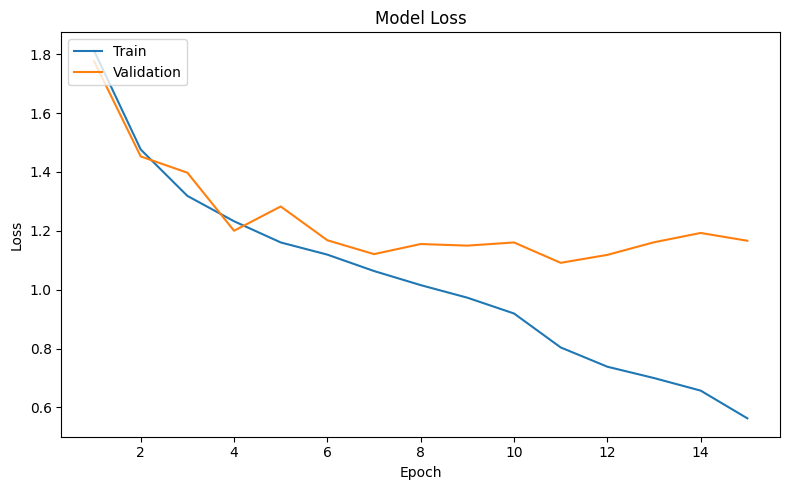

In [16]:
epochs_ran = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history['loss'], label='Train')
plt.plot(epochs_ran, history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(output_dir / 'loss.png', dpi=150)
plt.show()
plt.close()

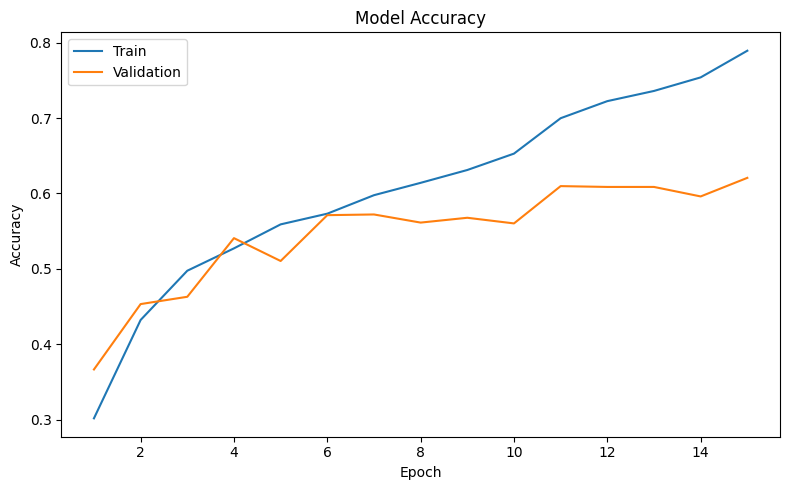

In [17]:
epochs_ran = range(1, len(history.history['accuracy']) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history['accuracy'], label='Train')
plt.plot(epochs_ran, history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(output_dir / 'accuracy.png', dpi=150)
plt.show()
plt.close()

**Saving Model**

In [19]:
architecture_path = output_dir / "emotion_model.json"
final_weights_path = output_dir / "emotion_model.weights.h5"
architecture_path.write_text(model.to_json(), encoding="utf-8")
model.save_weights(str(final_weights_path))

reloaded_model = model_from_json(architecture_path.read_text(encoding="utf-8"))
reloaded_model.load_weights(str(final_weights_path))
reloaded_model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
test_generator.reset()
test_batch, _ = test_generator[0]
np.testing.assert_allclose(
    model.predict(test_batch, verbose=0),
    reloaded_model.predict(test_batch, verbose=0),
    rtol=1e-5,
    atol=1e-6,
)
print("Saved and reloaded model files:")
print(architecture_path)
print(final_weights_path)

Saved and reloaded model files:
C:\Users\vipin\Downloads\Emotion_detection-main\Emotion_detection-main\training_outputs\20261009_212629_381020\emotion_model.json
C:\Users\vipin\Downloads\Emotion_detection-main\Emotion_detection-main\training_outputs\20261009_212629_381020\emotion_model.weights.h5
